**STEP 1 — Load & Explore the Data**

In [ ]:
import pandas as pd

df = pd.read_csv('supermarket_sales.csv')

# Basic info
print("Shape:", df.shape)           # Should show (1000, 17)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 17)

Columns: ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

First 5 rows:


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


**STEP 2 - Check data type and missing values**

In [ ]:
# Check data types
print(df.info())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

**STEP 3 — Data Cleaning & Transformation**

In [ ]:
# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Fix Date column — convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Add useful columns for analysis
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day_name()

# Rename columns for easier use
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Confirm cleaning
print("\nCleaned Data Types:")
print(df.dtypes)
df.head()

Duplicates: 0

Cleaned Data Types:
invoice_id                         object
branch                             object
city                               object
customer_type                      object
gender                             object
product_line                       object
unit_price                        float64
quantity                            int64
tax_5%                            float64
total                             float64
date                       datetime64[ns]
time                               object
payment                            object
cogs                              float64
gross_margin_percentage           float64
gross_income                      float64
rating                            float64
month                              object
day                                object
dtype: object


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,total,date,time,payment,cogs,gross_margin_percentage,gross_income,rating,month,day
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1,January,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6,March,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4,March,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4,January,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3,February,Friday


**STEP 4 — Analysis (Most Important!)
**

**4A — Top performing product categories:**

In [ ]:
top_products = df.groupby('product_line')['total'].sum().sort_values(ascending=False).reset_index()
top_products.columns = ['Product Line', 'Total Revenue']
top_products['Total Revenue'] = top_products['Total Revenue'].round(2)
print(top_products)

             Product Line  Total Revenue
0      Food and beverages       56144.84
1       Sports and travel       55122.83
2  Electronic accessories       54337.53
3     Fashion accessories       54305.90
4      Home and lifestyle       53861.91
5       Health and beauty       49193.74


**4B — Monthly revenue trend**

In [ ]:
monthly = df.groupby('month')['total'].sum().reset_index()
monthly.columns = ['Month', 'Revenue']
monthly = monthly.sort_values('Revenue', ascending=False)
print(monthly)

      Month     Revenue
1   January  116291.868
2     March  109455.507
0  February   97219.374


**4C — Customer purchase patterns**


In [ ]:
customer = df.groupby(['customer_type', 'gender'])['total'].agg(['mean','count']).reset_index()
customer.columns = ['Customer Type', 'Gender', 'Avg Spend', 'Visits']
customer['Avg Spend'] = customer['Avg Spend'].round(2)
print(customer)

  Customer Type  Gender  Avg Spend  Visits
0        Member  Female     337.73     261
1        Member    Male     316.99     240
2        Normal  Female     332.23     240
3        Normal    Male     305.05     259


**4D — Payment method breakdown**

In [ ]:
payment = df.groupby('payment')['total'].sum().reset_index()
payment.columns = ['Payment Method', 'Total Revenue']
print(payment)

  Payment Method  Total Revenue
0           Cash     112206.570
1    Credit card     100767.072
2        Ewallet     109993.107


**STEP 5 — Visualizations in Colab**


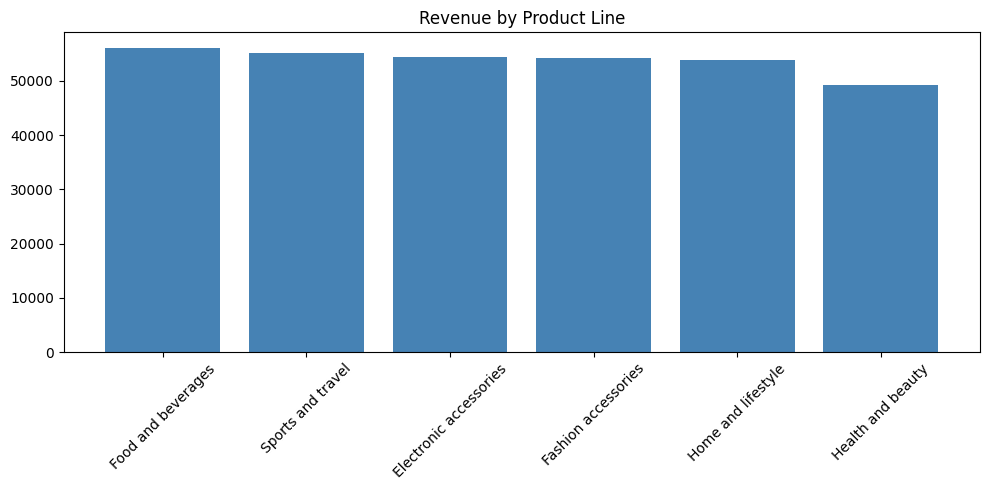

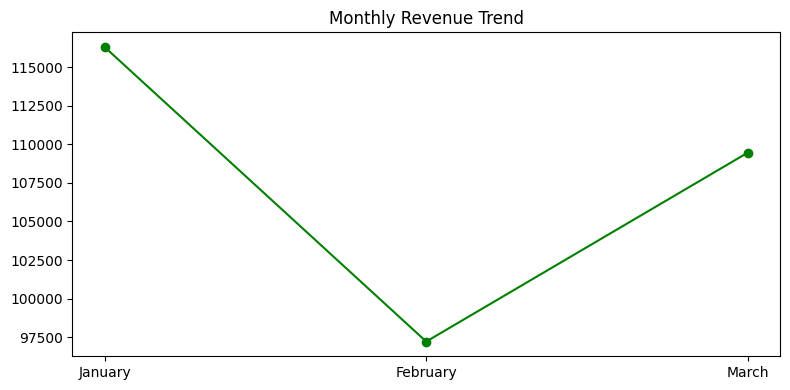

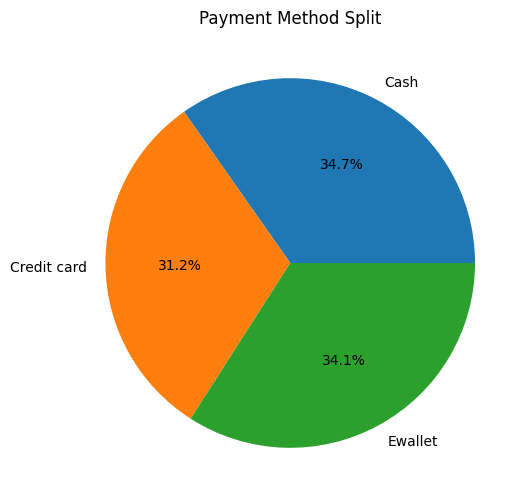

In [ ]:
import matplotlib.pyplot as plt

# Chart 1 — Top Product Lines
plt.figure(figsize=(10,5))
plt.bar(top_products['Product Line'], top_products['Total Revenue'], color='steelblue')
plt.title('Revenue by Product Line')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 2 — Monthly Revenue
monthly_order = ['January','February','March']
monthly_sorted = monthly.set_index('Month').reindex(monthly_order)
plt.figure(figsize=(8,4))
plt.plot(monthly_sorted.index, monthly_sorted['Revenue'], marker='o', color='green')
plt.title('Monthly Revenue Trend')
plt.tight_layout()
plt.show()

# Chart 3 — Payment Methods
plt.figure(figsize=(6,6))
plt.pie(payment['Total Revenue'], labels=payment['Payment Method'], autopct='%1.1f%%')
plt.title('Payment Method Split')
plt.show()

In [ ]:
# Save cleaned file
df.to_csv('supermarket_cleaned.csv', index=False)

# Download to your laptop
from google.colab import files
files.download('supermarket_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df.columns.tolist())
print(len(df.columns))


['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_5%', 'total', 'date', 'time', 'payment', 'cogs', 'gross_margin_percentage', 'gross_income', 'rating', 'month', 'day']
19
